In [1]:
import pandas as pd
import matplotlib.pyplot as plt

device=pd.read_csv("../data/r4.2/device.csv", nrows=300000)
device.shape

(300000, 5)

In [2]:
device.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   id        300000 non-null  str  
 1   date      300000 non-null  str  
 2   user      300000 non-null  str  
 3   pc        300000 non-null  str  
 4   activity  300000 non-null  str  
dtypes: str(5)
memory usage: 11.4 MB


In [3]:
device.describe()

,id,date,user,pc,activity
count,300000,300000,300000,300000,300000
unique,300000,295598,257,965,2
top,{J1S3-L9UU75BQ-7790ATPL},07/09/2010 09:48:08,AJF0370,PC-3640,Connect
freq,1,4,5998,5520,150494


In [4]:
device.head()

,id,date,user,pc,activity
0,{J1S3-L9UU75BQ-7790ATPL},01/02/2010 07:21:06,MOH0273,PC-6699,Connect
1,{N7B5-Y7BB27SI-2946PUJK},01/02/2010 07:37:41,MOH0273,PC-6699,Disconnect
2,{U1V9-Z7XT67KV-5649MYHI},01/02/2010 07:59:11,HPH0075,PC-2417,Connect
3,{H0Z7-E6GB57XZ-1603MOXD},01/02/2010 07:59:49,IIW0249,PC-0843,Connect
4,{L7P2-G4PX02RX-7999GYOY},01/02/2010 08:04:26,IIW0249,PC-0843,Disconnect


In [5]:
device.tail()

,id,date,user,pc,activity
299995,{L0L2-I9XN38YR-1571XKKZ},12/22/2010 08:53:32,LIM0674,PC-9582,Disconnect
299996,{G0W8-B6DT59BO-0524HQDO},12/22/2010 08:53:53,HDS0367,PC-8680,Connect
299997,{R0C9-L3SB14SP-1682VKIE},12/22/2010 08:54:51,JBD0616,PC-1479,Disconnect
299998,{G1Q4-T9ZF91GL-0622ICTH},12/22/2010 08:56:43,GZC0735,PC-8219,Connect
299999,{R1P1-Q3EO37XS-6506YUEZ},12/22/2010 08:56:44,VMJ0546,PC-9000,Disconnect


In [6]:
device['date']=pd.to_datetime(device['date'])

In [7]:
device.isnull().sum()

id          0
date        0
user        0
pc          0
activity    0
dtype: int64

In [8]:
# unique users 
device['user'].nunique()

257

In [9]:
device['user'].head(10)

0    MOH0273
1    MOH0273
2    HPH0075
3    IIW0249
4    IIW0249
5    HPH0075
6    HSB0196
7    RRC0553
8    MOH0273
9    MOH0273
Name: user, dtype: str

In [10]:
device['user'].tail(10)

299990    LCB0664
299991    IIW0249
299992    DPM0423
299993    IIW0249
299994    IIW0249
299995    LIM0674
299996    HDS0367
299997    JBD0616
299998    GZC0735
299999    VMJ0546
Name: user, dtype: str

In [11]:
# unique computers 
device['pc'].nunique()

965

In [12]:
device['pc'].head(10)

0    PC-6699
1    PC-6699
2    PC-2417
3    PC-0843
4    PC-0843
5    PC-2417
6    PC-8001
7    PC-6672
8    PC-6699
9    PC-6699
Name: pc, dtype: str

In [13]:
device['pc'].tail(10)

299990    PC-3196
299991    PC-0843
299992    PC-2567
299993    PC-0843
299994    PC-0843
299995    PC-9582
299996    PC-8680
299997    PC-1479
299998    PC-8219
299999    PC-9000
Name: pc, dtype: str

In [14]:
device['activity'].unique()

<StringArray>
['Connect', 'Disconnect']
Length: 2, dtype: str

In [15]:
device['activity'].value_counts()

activity
Connect       150494
Disconnect    149506
Name: count, dtype: int64

In [16]:
device.groupby('activity').count()

,id,date,user,pc
activity,,,,
Connect,150494,150494,150494,150494
Disconnect,149506,149506,149506,149506


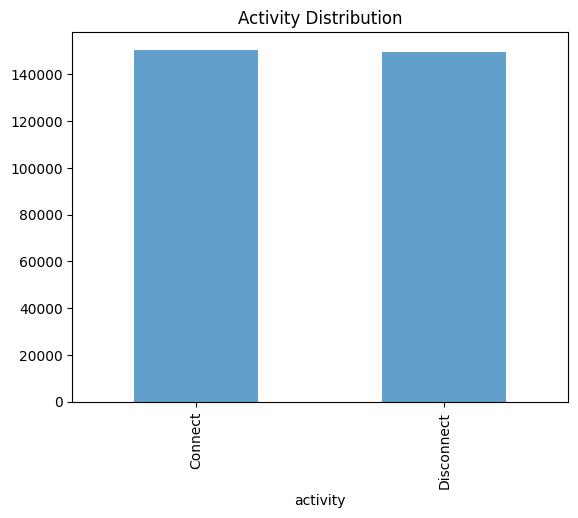

In [17]:
device['activity'].value_counts().plot(kind='bar',alpha=0.7)
plt.title("Activity Distribution")
plt.show()

the count of connected and disconected devices are same i.e its the normal activity


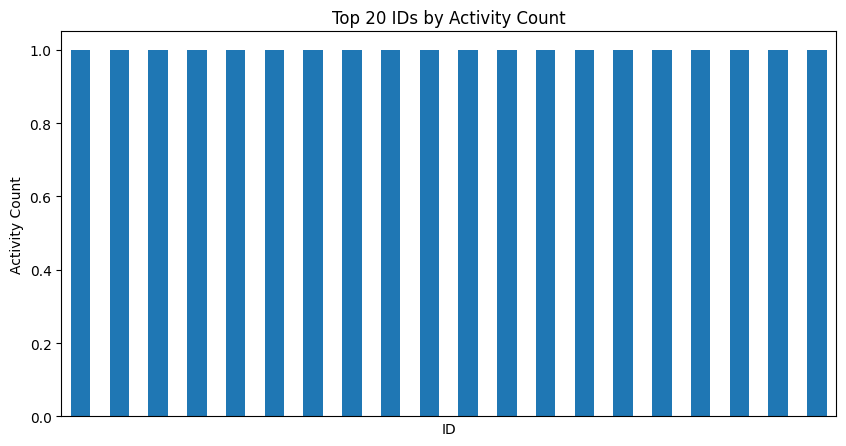

In [18]:
activity_per_id = device.groupby('id')['activity'].count().sort_values(ascending=False).head(20)

activity_per_id.plot(kind='bar', figsize=(10,5))
plt.title("Top 20 IDs by Activity Count")
plt.xticks([])
plt.xlabel("ID")
plt.ylabel("Activity Count")
plt.show()

Every ID has activity count = 1
That means each ID appears only once in the dataset
So there are no repeated users/devices

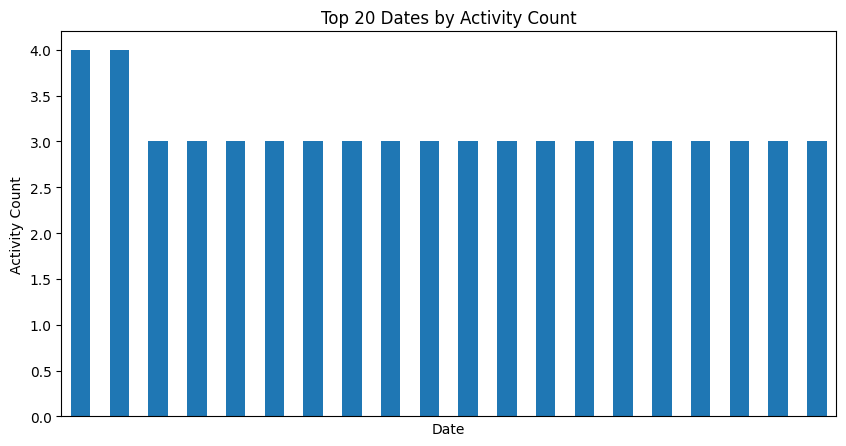

In [19]:
activity_per_date = device['date'].value_counts().head(20)

activity_per_date.plot(kind='bar', figsize=(10,5))
plt.title("Top 20 Dates by Activity Count")
plt.xticks([])
plt.xlabel("Date")
plt.ylabel("Activity Count")
plt.show()

Highest activity on some dates = 4 activities
Most other dates = 3 activities

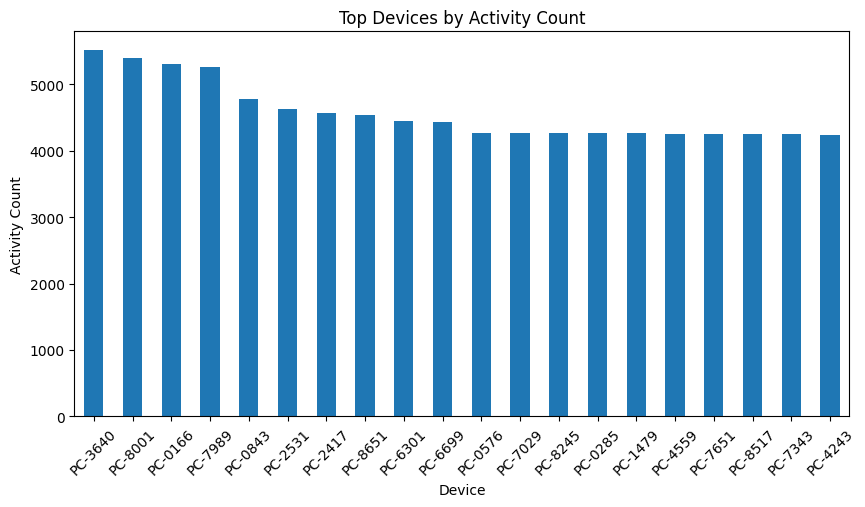

In [20]:
activity_per_device = device['pc'].value_counts().head(20)

activity_per_device.plot(kind='bar', figsize=(10,5))
plt.title("Top Devices by Activity Count")
plt.xticks(rotation=45)
plt.xlabel("Device")
plt.ylabel("Activity Count")
plt.show()

Observations from the chart:
Some devices like PC-3840, PC-8001, PC-0166, PC-7989 have the highest activity counts.
Activity counts range roughly from ~5500 down to ~4200.
The difference between devices is not extremely large.

([], [])

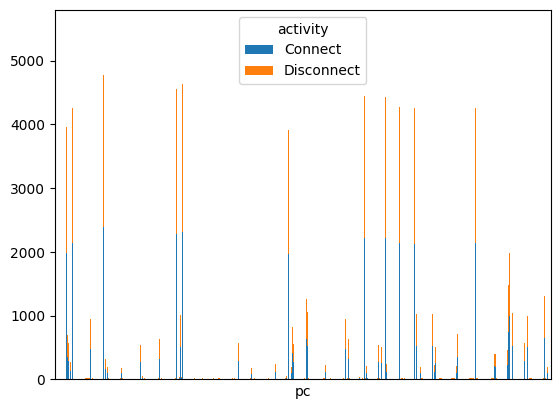

In [21]:
pd.crosstab(device['pc'], device['activity']).plot(kind='bar', stacked=True)
plt.xticks([])

In [22]:
device.groupby('id')['activity'].count().describe()

count    300000.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: activity, dtype: float64

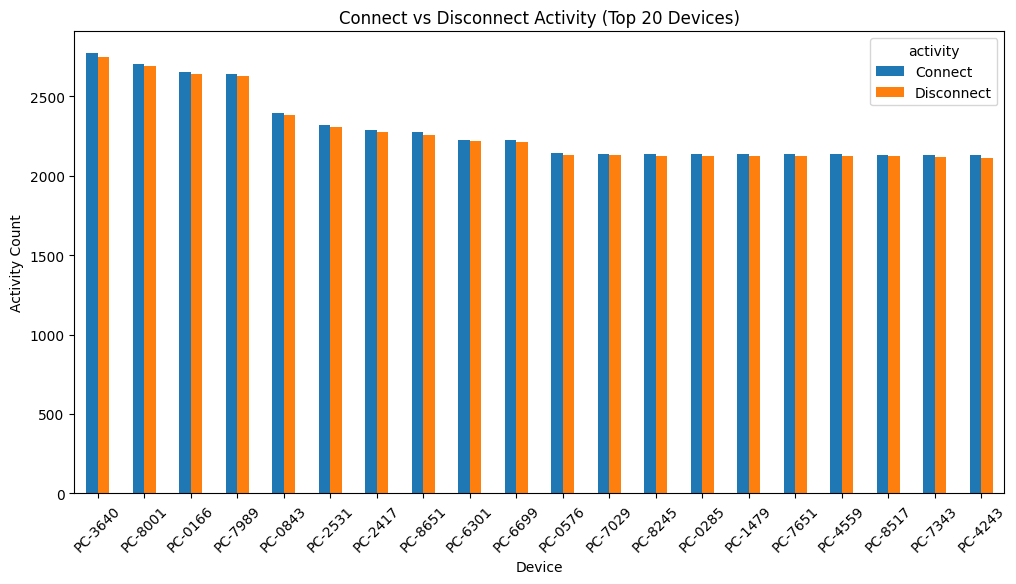

In [23]:
activity_counts = device.groupby(['pc','activity']).size().unstack()

top_devices = activity_counts.sum(axis=1).sort_values(ascending=False).head(20)

activity_counts.loc[top_devices.index].plot(kind='bar', figsize=(12,6))

plt.title("Connect vs Disconnect Activity (Top 20 Devices)")
plt.xlabel("Device")
plt.ylabel("Activity Count")
plt.xticks(rotation=45)
plt.show()

The comparison of connect and disconnect events per device shows that most devices maintain a balanced ratio between connection and disconnection activities. This indicates normal session behavior with no significant anomalies suggesting fraudulent activity